**Does Copy-Paste Augmentation Rescue the Rare Classes? A Study on a 4-Class ADE20K Subset**

In [1]:
# smp gives the U-Net + EfficientNet-B3 encoder and the losses; leave Colab's torch/torchvision as-is.
!pip install -q segmentation-models-pytorch==0.5.0 albumentations pycocotools
print("libraries ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.3 MB/s eta 0:00:00
libraries ready


In [2]:
import os, json, random, time, zipfile, ssl, glob
from collections import defaultdict
import numpy as np, pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pycocotools import mask as coco_mask
ssl._create_default_https_context = ssl._create_unverified_context
import warnings; warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| smp", smp.__version__, "| device", DEVICE)
if DEVICE.type != "cuda": print("Enable a GPU runtime before training.")

torch 2.11.0+cu128 | smp 0.5.0 | device cuda


**1 · Configuration, reproducibility and palette**

In [3]:
# configuration held in one dict, printed once so the whole run is reproducible from this cell
CFG = dict(zip_path="/content/RMDS_segmentation_dataset_ADE20K_350.zip", data_dir="/content/ade_waqas",
           out_dir="/content/waqas_out", img=384, batch=8, epochs=35, lr=3e-4, lr_pt=1e-4, wd=1e-4,
           patience=9, seed=313, workers=2, amp=True, paste_prob=0.7, paste_k=2)
os.makedirs(CFG["out_dir"], exist_ok=True)

def seed_all(s=CFG["seed"]):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_all()
GEN = torch.Generator().manual_seed(CFG["seed"])
RNG = random.Random(CFG["seed"])

CATID = {4: 1, 9: 2, 40: 3, 59: 4}           # VERIFIED from instances_train.json
CLASSES = ["background", "person", "car", "book", "airplane"]; NC = len(CLASSES)
FG = list(range(1, NC)); RARE = [3, 4]        # book, airplane are the copy-paste targets
# teal / orange palette (distinct)
HEX = ["#eef2f3", "#ef8354", "#4f8a8b", "#2b2d42", "#c1121f"]
PAL = np.array([[int(h[i:i+2], 16) for i in (1, 3, 5)] for h in HEX], np.uint8)
CMAP = ListedColormap(PAL / 255.0)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "#f7fafa", "axes.grid": True,
    "grid.color": "#e2eaea", "grid.linewidth": 0.7, "axes.titleweight": "bold", "axes.titlecolor": "#1f4e4f"})
print("config ready | rare-class paste targets:", [CLASSES[c] for c in RARE])

config ready | rare-class paste targets: ['book', 'airplane']


**2 · Decode COCO masks into label maps**

In [4]:
def find_root(base):
    hits = glob.glob(os.path.join(base, "**", "instances_train.json"), recursive=True)
    if not hits: raise FileNotFoundError("instances_train.json not found")
    return os.path.dirname(hits[0])

if not glob.glob(os.path.join(CFG["data_dir"], "**", "instances_train.json"), recursive=True):
    os.makedirs(CFG["data_dir"], exist_ok=True)
    assert os.path.exists(CFG["zip_path"]), f"upload the dataset to {CFG['zip_path']}"
    with zipfile.ZipFile(CFG["zip_path"]) as z: z.extractall(CFG["data_dir"])
ROOT = find_root(CFG["data_dir"]); print("data root:", ROOT)

def index_split(split):
    meta = json.load(open(os.path.join(ROOT, f"instances_{split}.json")))
    imgs = {im["id"]: im for im in meta["images"]}
    anns = defaultdict(list)
    for a in meta["annotations"]: anns[a["image_id"]].append(a)
    return imgs, anns

def rasterise(im, anns):
    lab = np.zeros((im["height"], im["width"]), np.uint8)
    for a in sorted(anns, key=lambda x: -x["area"]):
        c = CATID.get(a["category_id"])
        if c is not None: lab[coco_mask.decode(a["segmentation"]).astype(bool)] = c
    return lab

def cache(split):
    imgs, anns = index_split(split); mdir = os.path.join(CFG["out_dir"], "masks", split)
    os.makedirs(mdir, exist_ok=True); recs = []
    for iid, im in imgs.items():
        mp = os.path.join(mdir, os.path.splitext(im["file_name"])[0] + ".png")
        if not os.path.exists(mp): Image.fromarray(rasterise(im, anns[iid]), "L").save(mp)
        recs.append(dict(img=os.path.join(ROOT, split, im["file_name"]), msk=mp, file=im["file_name"]))
    return recs

def list_test():
    dd = os.path.join(ROOT, "test")
    return [dict(img=os.path.join(dd, f), file=f) for f in sorted(os.listdir(dd)) if f.lower().endswith(".jpg")]

t0 = time.time()
DATA = {"train": cache("train"), "val": cache("val"), "test": list_test()}
print(f"cached in {time.time()-t0:.1f}s | train {len(DATA['train'])}  val {len(DATA['val'])}  test {len(DATA['test'])} (unlabelled)")

data root: /content/ade_waqas
cached in 4.5s | train 350  val 350  test 30 (unlabelled)


In [5]:
# integrity: images and pixels per class
def stats(split):
    px = np.zeros(NC, np.int64); im = np.zeros(NC, int)
    for r in DATA[split]:
        b = np.bincount(np.asarray(Image.open(r["msk"])).ravel(), minlength=NC); px += b; im += (b > 0)
    return px, im
PIX, IMG = stats("train"); _, IMGV = stats("val")
print("train images/class:", {CLASSES[c]: int(IMG[c]) for c in range(NC)})
print("val   images/class:", {CLASSES[c]: int(IMGV[c]) for c in range(NC)})

train images/class: {'background': 350, 'person': 233, 'car': 148, 'book': 51, 'airplane': 5}
val   images/class: {'background': 350, 'person': 239, 'car': 136, 'book': 46, 'airplane': 7}


**3 · Exploratory data analysis (five views)**

In [6]:
rows = []
for split in ("train", "val"):
    imgs, anns = index_split(split)
    for iid, im in imgs.items():
        for a in anns[iid]:
            c = CATID.get(a["category_id"])
            if c: rows.append(dict(split=split, cls=CLASSES[c], areaf=a["area"] / (im["width"] * im["height"])))
OBJ = pd.DataFrame(rows); print("object instances:", len(OBJ))

object instances: 4292


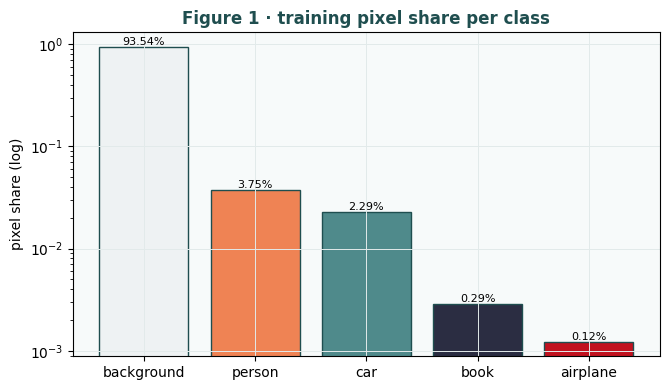

In [7]:
# Figure 1 - training pixel share per class (log scale so rare classes are visible)
share = PIX / PIX.sum()
fig, ax = plt.subplots(figsize=(6.8, 4))
b = ax.bar(CLASSES, np.maximum(share, 1e-5), color=[PAL[c] / 255 for c in range(NC)], edgecolor="#1f4e4f")
ax.set_yscale("log"); ax.set_ylabel("pixel share (log)")
for r, c in zip(b, range(NC)): ax.text(r.get_x()+r.get_width()/2, r.get_height(), f"{100*share[c]:.2f}%", ha="center", va="bottom", fontsize=8)
ax.set_title("Figure 1 · training pixel share per class"); plt.tight_layout(); plt.show()

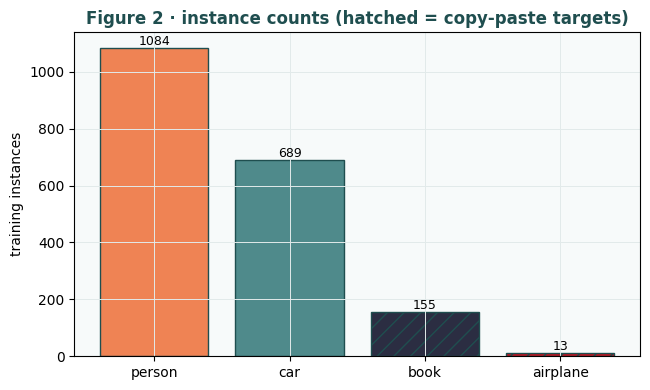

In [8]:
# Figure 2 - instance counts, highlighting the two rare paste-target classes
counts = OBJ[OBJ.split=="train"]["cls"].value_counts().reindex(CLASSES[1:]).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(6.6, 4))
bars = ax.bar(counts.index, counts.values, color=[PAL[c]/255 for c in FG], edgecolor="#1f4e4f")
for i, c in enumerate(FG):
    if c in RARE: bars[i].set_hatch("//")
for r, v in zip(bars, counts.values): ax.text(r.get_x()+r.get_width()/2, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_ylabel("training instances"); ax.set_title("Figure 2 · instance counts (hatched = copy-paste targets)")
plt.tight_layout(); plt.show()

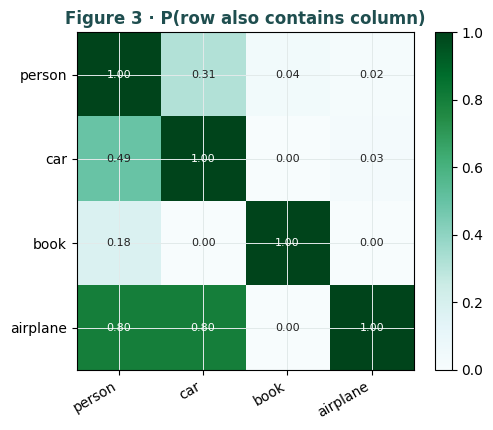

In [9]:
# Figure 3 - class co-occurrence P(row also has column)
imgs, anns = index_split("train"); present = [{CATID[a["category_id"]] for a in anns[i] if a["category_id"] in CATID} for i in imgs]
M = np.zeros((len(FG), len(FG)))
for i, a in enumerate(FG):
    ha = [p for p in present if a in p]
    for j, b in enumerate(FG): M[i, j] = np.mean([b in p for p in ha]) if ha else 0
fig, ax = plt.subplots(figsize=(5.2, 4.4)); im = ax.imshow(M, cmap="BuGn", vmin=0, vmax=1)
ax.set_xticks(range(len(FG))); ax.set_xticklabels(CLASSES[1:], rotation=30, ha="right"); ax.set_yticks(range(len(FG))); ax.set_yticklabels(CLASSES[1:])
for i in range(len(FG)):
    for j in range(len(FG)): ax.text(j, i, f"{M[i,j]:.2f}", ha="center", va="center", color="white" if M[i,j]>.5 else "#222", fontsize=8)
ax.set_title("Figure 3 · P(row also contains column)"); fig.colorbar(im, fraction=.046); plt.tight_layout(); plt.show()

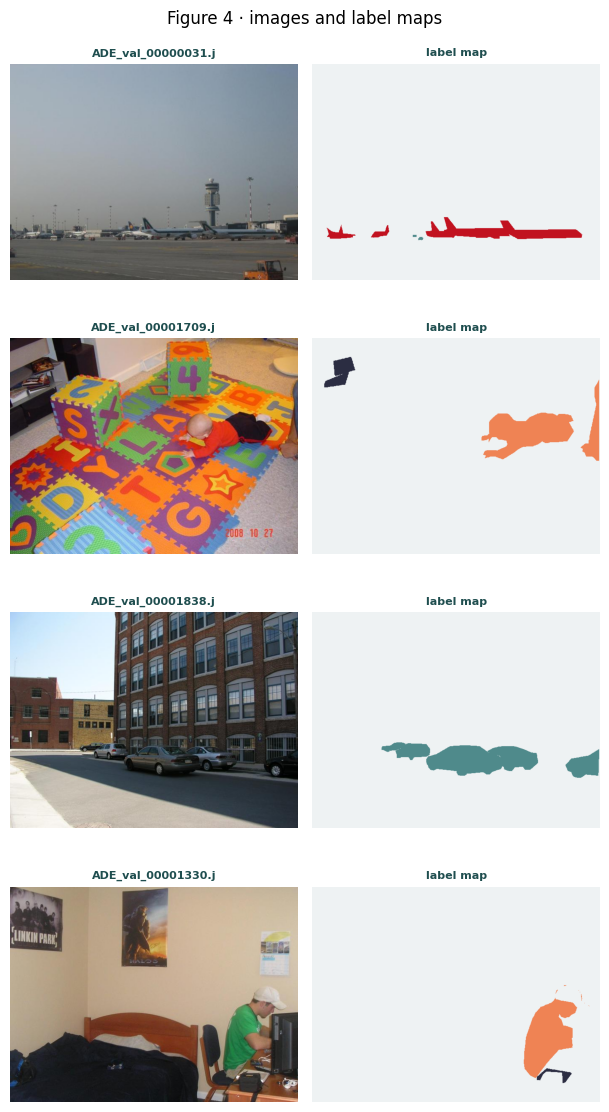

In [10]:
# Figure 4 - sample images and colour-coded label maps (one per foreground class)
by = {c: [r for r in DATA["train"] if c in np.unique(np.asarray(Image.open(r["msk"])))] for c in FG}
picks = [RNG.choice(by[c]) for c in [4, 3, 2, 1] if by[c]]
fig, ax = plt.subplots(len(picks), 2, figsize=(6.2, 2.9*len(picks)))
for r, rec in enumerate(picks):
    ax[r,0].imshow(Image.open(rec["img"]).convert("RGB")); ax[r,0].set_title(rec["file"][:18], fontsize=8)
    ax[r,1].imshow(PAL[np.asarray(Image.open(rec["msk"]))]); ax[r,1].set_title("label map", fontsize=8)
    for a in ax[r]: a.axis("off")
fig.suptitle("Figure 4 · images and label maps"); plt.tight_layout(); plt.show()

**4 · The copy-paste augmentor and the two data pipelines**

In [11]:
# build the rare-instance bank from connected components of book/airplane in the TRAIN masks
def build_bank():
    bank = []
    for r in DATA["train"]:
        lab = np.asarray(Image.open(r["msk"])); img = None
        for c in RARE:
            if not (lab == c).any(): continue
            n, comp = cv2.connectedComponents((lab == c).astype(np.uint8))
            for k in range(1, n):
                ys, xs = np.where(comp == k)
                if len(ys) < 64: continue                       # skip tiny specks
                if img is None: img = np.array(Image.open(r["img"]).convert("RGB"))
                y0, y1, x0, x1 = ys.min(), ys.max()+1, xs.min(), xs.max()+1
                bank.append((img[y0:y1, x0:x1].copy(), (comp[y0:y1, x0:x1] == k), c))
    return bank
RARE_BANK = build_bank()
print("rare-instance bank size:", len(RARE_BANK),
      "| book:", sum(1 for _,_,c in RARE_BANK if c==3), "| airplane:", sum(1 for _,_,c in RARE_BANK if c==4))

def copy_paste(img, lab, k):
    out_i, out_l = img.copy(), lab.copy(); H, W = lab.shape
    for _ in range(k):
        crop, m, c = RARE_BANK[RNG.randrange(len(RARE_BANK))]
        s = RNG.uniform(0.7, 1.3)
        ch, cw = max(8, int(crop.shape[0]*s)), max(8, int(crop.shape[1]*s))
        if ch >= H or cw >= W: continue
        ci = cv2.resize(crop, (cw, ch), interpolation=cv2.INTER_LINEAR)
        cm = cv2.resize(m.astype(np.uint8), (cw, ch), interpolation=cv2.INTER_NEAREST).astype(bool)
        y, x = RNG.randint(0, H-ch), RNG.randint(0, W-cw)
        out_i[y:y+ch, x:x+cw][cm] = ci[cm]; out_l[y:y+ch, x:x+cw][cm] = c
    return out_i, out_l

rare-instance bank size: 137 | book: 127 | airplane: 10


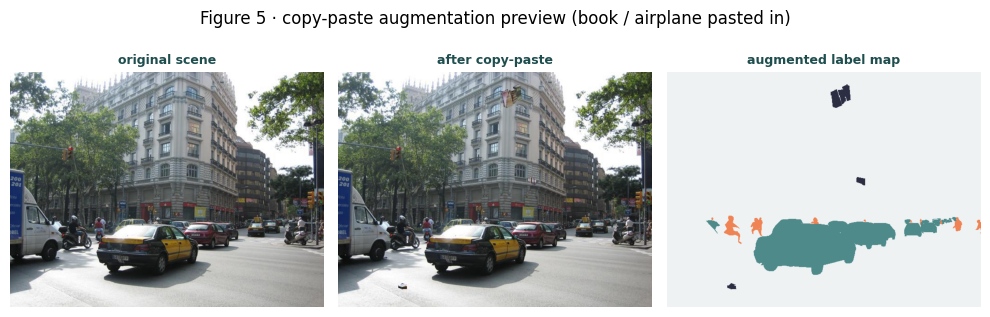

In [12]:
# Figure 5 - copy-paste PREVIEW: a base scene before and after pasting rare instances
base = RNG.choice([r for r in DATA["train"] if 2 in np.unique(np.asarray(Image.open(r["msk"])))])
bi = np.array(Image.open(base["img"]).convert("RGB")); bl = np.asarray(Image.open(base["msk"])).copy()
seed_all(); pi, pl = copy_paste(bi, bl, 3)
fig, ax = plt.subplots(1, 3, figsize=(10, 3.4))
ax[0].imshow(bi); ax[0].set_title("original scene", fontsize=9)
ax[1].imshow(pi); ax[1].set_title("after copy-paste", fontsize=9)
ax[2].imshow(PAL[pl]); ax[2].set_title("augmented label map", fontsize=9)
for a in ax: a.axis("off")
fig.suptitle("Figure 5 · copy-paste augmentation preview (book / airplane pasted in)"); plt.tight_layout(); plt.show()

In [13]:
IMEAN, ISTD = (0.485,0.456,0.406), (0.229,0.224,0.225)
def aug_train(s): return A.Compose([A.Resize(s,s), A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(0.06,0.1,15,border_mode=0,p=0.4), A.RandomBrightnessContrast(0.2,0.2,p=0.5),
    A.Normalize(IMEAN,ISTD), ToTensorV2()])
def aug_eval(s): return A.Compose([A.Resize(s,s), A.Normalize(IMEAN,ISTD), ToTensorV2()])

class SegSet(Dataset):
    """copy_paste=True applies the rare-instance paste BEFORE resize/normalise; otherwise identical."""
    def __init__(self, recs, tf, copy_paste_on=False):
        self.r, self.tf, self.cp = recs, tf, copy_paste_on
    def __len__(self): return len(self.r)
    def __getitem__(self, i):
        r = self.r[i]
        img = np.array(Image.open(r["img"]).convert("RGB")); msk = np.asarray(Image.open(r["msk"]))
        if self.cp and RARE_BANK and RNG.random() < CFG["paste_prob"]:
            img, msk = copy_paste(img, msk, CFG["paste_k"])
        o = self.tf(image=img, mask=np.ascontiguousarray(msk)); return o["image"], o["mask"].long(), r["file"]

def worker_seed(w): np.random.seed(CFG["seed"]+w); random.seed(CFG["seed"]+w)
def make_loader(copy_paste_on):
    return DataLoader(SegSet(DATA["train"], aug_train(CFG["img"]), copy_paste_on), batch_size=CFG["batch"],
                      shuffle=True, num_workers=CFG["workers"], pin_memory=True, worker_init_fn=worker_seed, drop_last=True)
val_dl = DataLoader(SegSet(DATA["val"], aug_eval(CFG["img"])), batch_size=CFG["batch"], shuffle=False,
                    num_workers=CFG["workers"], pin_memory=True, worker_init_fn=worker_seed)
xb, yb, _ = next(iter(make_loader(True))); print("batch", tuple(xb.shape), "| labels", torch.unique(yb).tolist())

batch (8, 3, 384, 384) | labels [0, 1, 2, 3]


**5 · Dice + Focal loss and per-class IoU / Dice metrics**

In [14]:
class DiceFocal(nn.Module):
    def __init__(self):
        super().__init__(); self.dice = smp.losses.DiceLoss(mode="multiclass")
        self.focal = smp.losses.FocalLoss(mode="multiclass", gamma=2.0)
    def forward(self, logits, y): return self.dice(logits, y) + self.focal(logits, y)

class Meter:
    def __init__(self, k=NC): self.k=k; self.cm=np.zeros((k,k), np.int64)
    def add(self, logits, y):
        p=logits.argmax(1).cpu().numpy().ravel(); t=y.cpu().numpy().ravel()
        self.cm += np.bincount(t*self.k+p, minlength=self.k**2).reshape(self.k,self.k)
    def scores(self):
        cm=self.cm.astype(float); tp=np.diag(cm); fp=cm.sum(0)-tp; fn=cm.sum(1)-tp
        iou=tp/np.maximum(tp+fp+fn,1e-9); dice=2*tp/np.maximum(2*tp+fp+fn,1e-9)
        seen=[c for c in FG if cm[c].sum()>0]
        return dict(iou=iou, dice=dice, cm=cm, miou=float(np.mean([iou[c] for c in seen])) if seen else 0.0,
                    mdice=float(np.mean([dice[c] for c in seen])) if seen else 0.0)
_t=torch.randint(0,NC,(2,16,16)); _m=Meter(); _m.add(F.one_hot(_t,NC).permute(0,3,1,2).float(),_t)
print("perfect-prediction fg mIoU:", round(_m.scores()["miou"],3))

perfect-prediction fg mIoU: 1.0


**6 · Models: a trained U-Net and a pre-trained baseline**

In [15]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
class PretrainedDeepLab(nn.Module):
    def __init__(self, n):
        super().__init__(); net = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
        net.classifier[-1] = nn.Conv2d(256, n, 1); net.aux_classifier = None; self.net = net
    def forward(self, x): return self.net(x)["out"]

def build(key):
    if key in ("baseline", "copypaste"):
        return smp.Unet(encoder_name="timm-efficientnet-b3", encoder_weights="imagenet", in_channels=3, classes=NC)
    if key == "deeplab_pt": return PretrainedDeepLab(NC)
    raise ValueError(key)
SPEC = {"baseline": dict(lr=CFG["lr"], cp=False), "copypaste": dict(lr=CFG["lr"], cp=True), "deeplab_pt": dict(lr=CFG["lr_pt"], cp=False)}
for k in SPEC:
    m=build(k); print(f"{k:10s} {sum(p.numel() for p in m.parameters())/1e6:5.1f}M params"); del m

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

baseline    13.2M params
copypaste   13.2M params
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [00:00<00:00, 214MB/s]


deeplab_pt  39.6M params


**7 · Training engine (AMP, cosine LR, early stopping on val foreground mIoU)**

In [16]:
@torch.inference_mode()
def evaluate(model):
    model.eval(); mt=Meter()
    for x,y,_ in val_dl:
        with torch.autocast("cuda", enabled=CFG["amp"]): logits=model(x.to(DEVICE))
        mt.add(logits.float(), y.to(DEVICE))
    return mt.scores()

def fit(key):
    seed_all(); GEN.manual_seed(CFG["seed"])
    model=build(key).to(DEVICE); crit=DiceFocal().to(DEVICE)
    loader=make_loader(SPEC[key]["cp"])
    opt=torch.optim.AdamW(model.parameters(), lr=SPEC[key]["lr"], weight_decay=CFG["wd"])
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG["epochs"])
    scaler=torch.amp.GradScaler("cuda", enabled=CFG["amp"])
    best={"miou":-1}; ckpt=os.path.join(CFG["out_dir"], f"{key}.pt"); hist=[]; wait=0
    for ep in range(1, CFG["epochs"]+1):
        model.train(); run=0.0
        for x,y,_ in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=CFG["amp"]): loss=crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run+=loss.item()*x.size(0)
        sch.step(); s=evaluate(model); s["epoch"]=ep; s["loss"]=run/len(loader.dataset); hist.append(s)
        if s["miou"]>best["miou"]: best=s; torch.save(model.state_dict(), ckpt); wait=0
        else: wait+=1
        print(f"[{key}] ep{ep:02d} loss {s['loss']:.3f} | val mIoU {s['miou']:.3f} (best {best['miou']:.3f}) | "
              +" ".join(f"{CLASSES[c][:4]} {s['iou'][c]:.2f}" for c in FG))
        if wait>=CFG["patience"]: print(f"[{key}] early stop"); break
    return dict(key=key, best=best, ckpt=ckpt, hist=pd.DataFrame([{k:h[k] for k in ("epoch","loss","miou","mdice")} for h in hist]))

**8 · Train the three models and rank by validation foreground mIoU**

In [17]:
RESULTS=[fit(k) for k in ("baseline","copypaste","deeplab_pt")]
board=pd.DataFrame([{"model":r["key"], "val_mIoU":r["best"]["miou"], "val_mDice":r["best"]["mdice"],
    **{f"IoU_{CLASSES[c]}":r["best"]["iou"][c] for c in FG}} for r in RESULTS]).sort_values("val_mIoU", ascending=False).reset_index(drop=True)
board.to_csv(os.path.join(CFG["out_dir"],"leaderboard.csv"), index=False)
print("\nLeaderboard (validation):"); print(board.round(3).to_string(index=False))
if len(RESULTS)>=2:
    base=next(r for r in RESULTS if r["key"]=="baseline"); cp=next(r for r in RESULTS if r["key"]=="copypaste")
    print("\ncopy-paste minus baseline, per rare class:",
          {CLASSES[c]: round(cp["best"]["iou"][c]-base["best"]["iou"][c],3) for c in RARE})

[baseline] ep01 loss 1.931 | val mIoU 0.033 (best 0.033) | pers 0.01 car 0.11 book 0.01 airp 0.00
[baseline] ep02 loss 1.043 | val mIoU 0.052 (best 0.052) | pers 0.00 car 0.20 book 0.00 airp 0.00
[baseline] ep03 loss 0.882 | val mIoU 0.054 (best 0.054) | pers 0.00 car 0.22 book 0.00 airp 0.00
[baseline] ep04 loss 0.750 | val mIoU 0.080 (best 0.080) | pers 0.05 car 0.27 book 0.00 airp 0.00
[baseline] ep05 loss 0.666 | val mIoU 0.226 (best 0.226) | pers 0.44 car 0.46 book 0.00 airp 0.00
[baseline] ep06 loss 0.620 | val mIoU 0.250 (best 0.250) | pers 0.51 car 0.49 book 0.00 airp 0.00
[baseline] ep07 loss 0.568 | val mIoU 0.276 (best 0.276) | pers 0.54 car 0.56 book 0.00 airp 0.00
[baseline] ep08 loss 0.508 | val mIoU 0.287 (best 0.287) | pers 0.54 car 0.60 book 0.00 airp 0.00
[baseline] ep09 loss 0.486 | val mIoU 0.289 (best 0.289) | pers 0.57 car 0.59 book 0.00 airp 0.00
[baseline] ep10 loss 0.450 | val mIoU 0.301 (best 0.301) | pers 0.58 car 0.63 book 0.00 airp 0.00
[baseline] ep11 loss

In [18]:
# rubric (e) - per-class Dice for every model, reusing the same stored best-epoch score dicts as the IoU leaderboard
dice_board=pd.DataFrame([{"model":r["key"], "val_mDice":r["best"]["mdice"],
    **{f"Dice_{CLASSES[c]}":r["best"]["dice"][c] for c in range(NC)}} for r in RESULTS]).sort_values("val_mDice", ascending=False).reset_index(drop=True)
dice_board.to_csv(os.path.join(CFG["out_dir"],"leaderboard_dice.csv"), index=False)
print("\nPer-class Dice (validation):"); print(dice_board.round(3).to_string(index=False))


Per-class Dice (validation):
     model  val_mDice  Dice_background  Dice_person  Dice_car  Dice_book  Dice_airplane
 copypaste      0.590            0.982        0.754     0.781      0.378          0.447
deeplab_pt      0.558            0.984        0.784     0.807      0.383          0.259
  baseline      0.507            0.983        0.770     0.806      0.450          0.000


**9 · Analysis of the best model**

best: copypaste | val mIoU 0.442


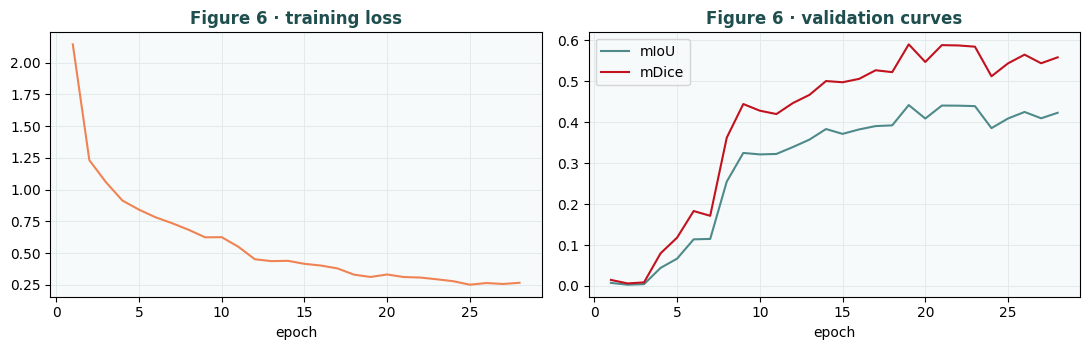

In [19]:
best=max(RESULTS, key=lambda r: r["best"]["miou"])
print("best:", best["key"], "| val mIoU", round(best["best"]["miou"],3))
model=build(best["key"]).to(DEVICE); model.load_state_dict(torch.load(best["ckpt"], map_location=DEVICE)); model.eval()
h=best["hist"]; fig,ax=plt.subplots(1,2,figsize=(11,3.6))
ax[0].plot(h["epoch"],h["loss"],color=PAL[1]/255); ax[0].set_title("Figure 6 · training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(h["epoch"],h["miou"],color=PAL[2]/255,label="mIoU"); ax[1].plot(h["epoch"],h["mdice"],color=PAL[4]/255,label="mDice")
ax[1].set_title("Figure 6 · validation curves"); ax[1].set_xlabel("epoch"); ax[1].legend(); plt.tight_layout(); plt.show()

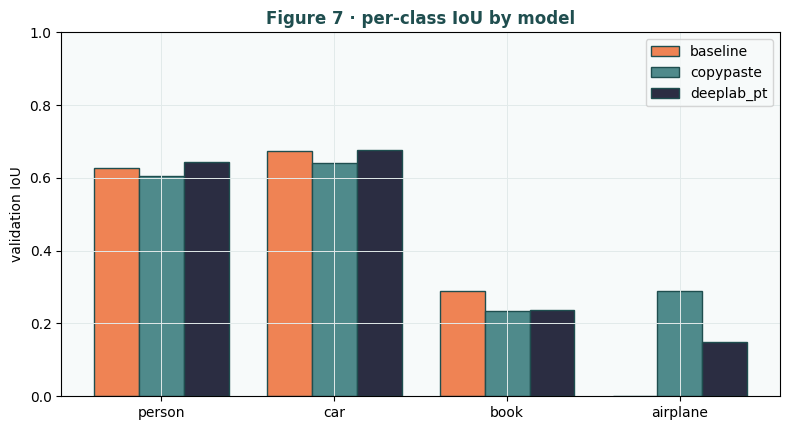

In [20]:
# Figure 7 - per-class IoU across the three models
x=np.arange(len(FG)); w=0.26; fig,ax=plt.subplots(figsize=(8,4.4))
for k,r in enumerate(RESULTS):
    ax.bar(x+(k-1)*w, [r["best"]["iou"][c] for c in FG], w, label=r["key"], color=PAL[k+1]/255, edgecolor="#1f4e4f")
ax.set_xticks(x); ax.set_xticklabels(CLASSES[1:]); ax.set_ylim(0,1); ax.set_ylabel("validation IoU")
ax.set_title("Figure 7 · per-class IoU by model"); ax.legend(); plt.tight_layout(); plt.show()

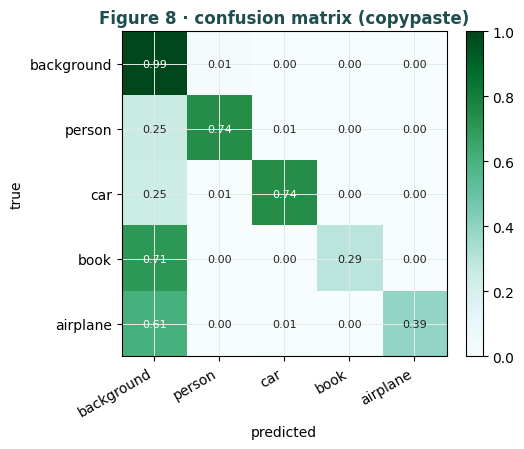

VAL per-class IoU: {'person': np.float64(0.605), 'car': np.float64(0.641), 'book': np.float64(0.233), 'airplane': np.float64(0.288)}


In [21]:
# Figure 8 - confusion matrix of the best model (row-normalised)
cm=evaluate(model)["cm"]; cmn=cm/np.maximum(cm.sum(1,keepdims=True),1)
fig,ax=plt.subplots(figsize=(5.4,4.6)); im=ax.imshow(cmn,cmap="BuGn",vmin=0,vmax=1)
ax.set_xticks(range(NC)); ax.set_xticklabels(CLASSES,rotation=30,ha="right"); ax.set_yticks(range(NC)); ax.set_yticklabels(CLASSES)
for i in range(NC):
    for j in range(NC): ax.text(j,i,f"{cmn[i,j]:.2f}",ha="center",va="center",color="white" if cmn[i,j]>.5 else "#222",fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(f"Figure 8 · confusion matrix ({best['key']})")
fig.colorbar(im,fraction=.046); plt.tight_layout(); plt.show()
print("VAL per-class IoU:", {CLASSES[c]: round(best["best"]["iou"][c],3) for c in FG})

**9.1 — Qualitative predictions on the unlabelled test images (≥3).**

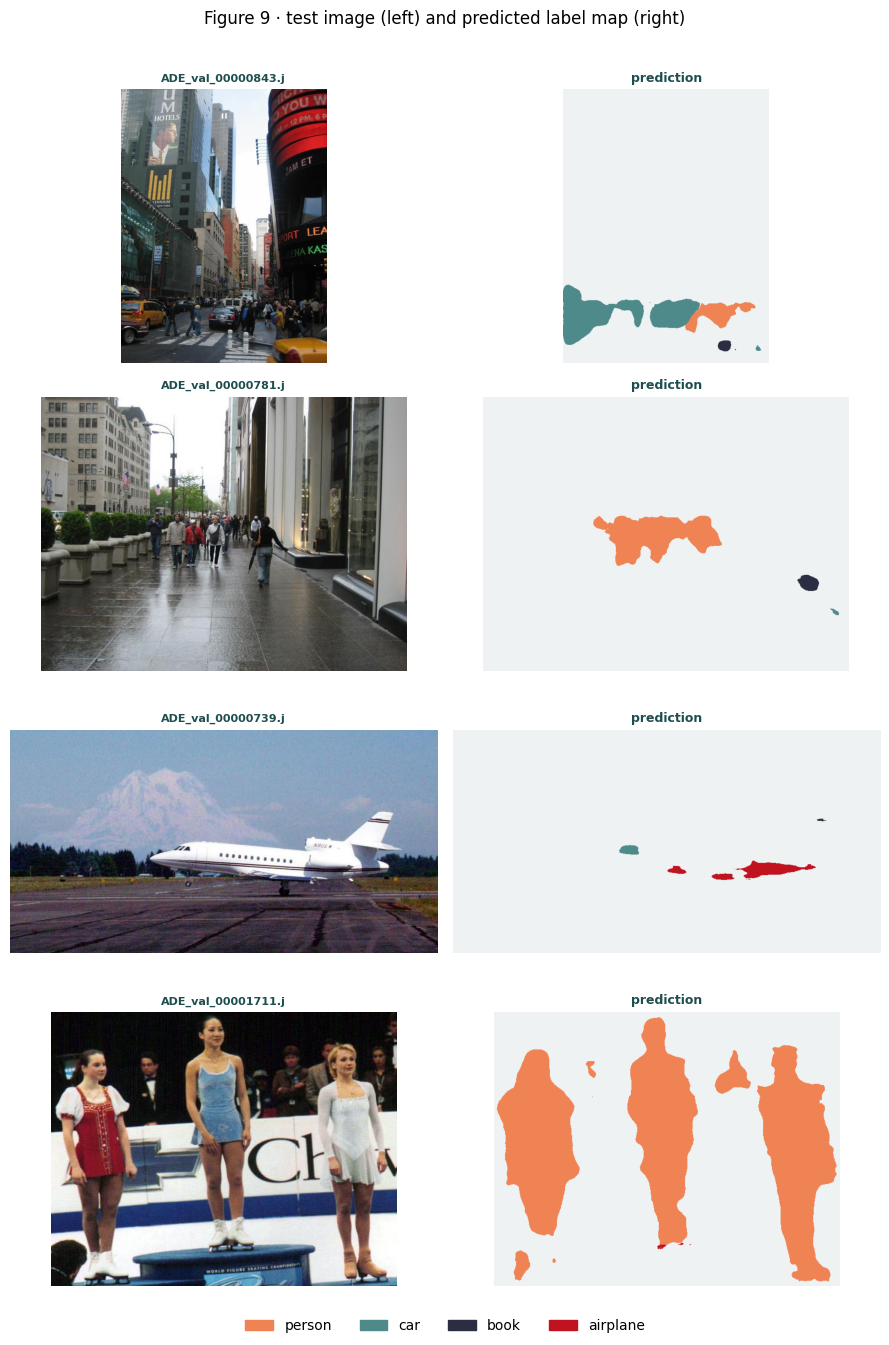

Test is unlabelled -> qualitative only; metrics are on the validation split.


In [22]:
@torch.inference_mode()
def predict(model, image):
    H,W=image.shape[:2]; t=aug_eval(CFG["img"])(image=image, mask=np.zeros((H,W),np.uint8))["image"][None].to(DEVICE)
    lo=F.interpolate(model(t), size=(H,W), mode="bilinear", align_corners=False); return lo.argmax(1)[0].cpu().numpy().astype(np.uint8)
def test_panels(model, n=4):
    ranked=[]
    for r in DATA["test"]:
        pr=predict(model, np.array(Image.open(r["img"]).convert("RGB"))); ranked.append((len(set(np.unique(pr))-{0}), int((pr>0).sum()), r))
    ranked.sort(key=lambda t:(-t[0],-t[1])); picks=[t[2] for t in ranked[:n]]
    fig,ax=plt.subplots(n,2,figsize=(9,3.4*n))
    for i,r in enumerate(picks):
        img=np.array(Image.open(r["img"]).convert("RGB")); pr=predict(model,img)
        ax[i,0].imshow(img); ax[i,0].set_title(r["file"][:18],fontsize=8); ax[i,0].axis("off")
        ax[i,1].imshow(PAL[pr]); ax[i,1].set_title("prediction",fontsize=9); ax[i,1].axis("off")
    from matplotlib.patches import Patch
    fig.legend(handles=[Patch(color=PAL[c]/255,label=CLASSES[c]) for c in FG], loc="lower center", ncol=4, frameon=False)
    fig.suptitle("Figure 9 · test image (left) and predicted label map (right)"); plt.tight_layout(rect=[0,.03,1,.97]); plt.show()
test_panels(model, n=4)
print("Test is unlabelled -> qualitative only; metrics are on the validation split.")

**10 · Reusable inference on any image, and saved artefacts**

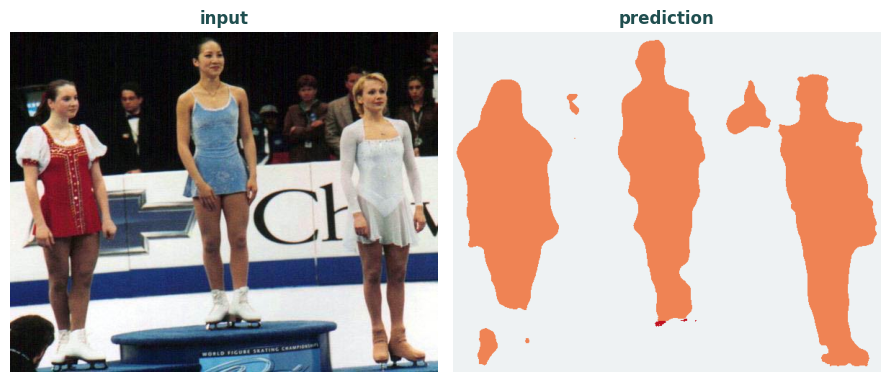

classes detected: ['person', 'airplane']
saved best model + leaderboard to /content/waqas_out


In [23]:
def infer(path, model=model):
    img=np.array(Image.open(path).convert("RGB")); pr=predict(model,img)
    fig,ax=plt.subplots(1,2,figsize=(9,4)); ax[0].imshow(img); ax[0].set_title("input"); ax[0].axis("off")
    ax[1].imshow(PAL[pr]); ax[1].set_title("prediction"); ax[1].axis("off"); plt.tight_layout(); plt.show()
    print("classes detected:", [CLASSES[c] for c in np.unique(pr) if c>0] or ["background only"])
_r=sorted(DATA["test"], key=lambda r:-int((predict(model,np.array(Image.open(r["img"]).convert("RGB")))>0).sum()))
infer(_r[0]["img"])
import shutil; shutil.copy(best["ckpt"], os.path.join(CFG["out_dir"],"best_model.pt"))
board.to_csv(os.path.join(CFG["out_dir"],"leaderboard.csv"), index=False)
print("saved best model + leaderboard to", CFG["out_dir"])